# Calibrating to the Mean and Standard Deviation with WGMS Data

The scalar mass balance calibration technique currently only calibrates one parameter at a time and calibrates to the reference average mass balance only. We will be aiming to improve the calibration through the use of the WGMS dataset as this contains interannual data which can provide more metrics and data to calibrate to.

In this notebook we will:
Calibrate the mass balance parameters to minimize the mean and the standard deviation.

## Set Up

First install required packages to run this tutorial. 

We will be using level 4 data to allow for the dynamical spinup and the calibration capabilities.

In [68]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import os

import oggm
from oggm import cfg, utils, workflow, tasks, graphics
from oggm.sandbox.edu import run_constant_climate_with_bias
import xarray as xr
from oggm.core import massbalance
from oggm.core.massbalance import mb_calibration_from_scalar_mb, mb_calibration_from_geodetic_mb

In [69]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2025-11-20 17:10:20: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-11-20 17:10:20: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-11-20 17:10:20: oggm.cfg: Multiprocessing: using all available processors (N=22)
2025-11-20 17:10:20: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-11-20 17:10:20: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-11-20 17:10:20: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [70]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-11-20 17:10:21: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-20 17:10:21: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


# **Calibration:** Scalar Mass Balance Calibration with standard deviation added in and weighted in the cost function

Firstly, for using both the mean and standard deviation in the cost function together to reduce the ill-posedness of our problem we will need to check that they are independent:

2025-11-20 17:10:21: oggm.workflow: init_glacier_directories from prepro level 5 on 289 glaciers.
2025-11-20 17:10:21: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 289 glaciers
2025-11-20 17:10:21: oggm.workflow: WARNING: you are trying to run an entity task on 289 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
2025-11-20 17:11:19: oggm.utils: You are trying to set MB data on a tidewater glacier! These data will be ignored by the MB model calibration routine.
2025-11-20 17:11:19: oggm.utils: You are trying to set MB data on a tidewater glacier! These data will be ignored by the MB model calibration routine.
2025-11-20 17:11:19: oggm.utils: You are trying to set MB data on a tidewater glacier! These data will be ignored by the MB model calibration routine.
2025-11-20 17:11:20: oggm.utils: You are trying to set MB data on a tidewater glacier! These data will be ignored by the MB model calibration routine.
2025-11-20 17:11:22: o

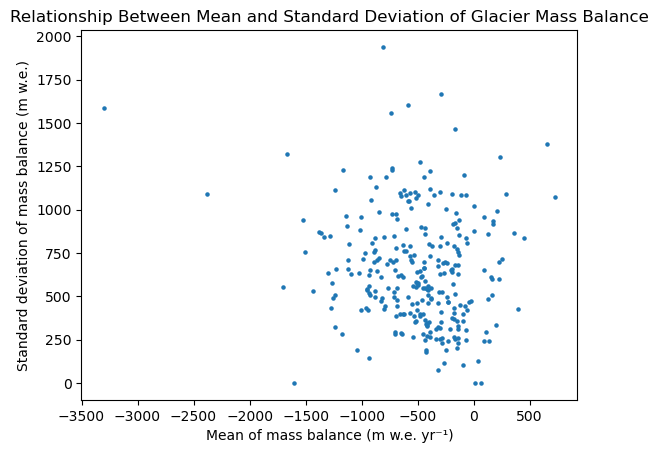

0.012613570986825404
-0.14657700943950233


In [71]:
from oggm.utils._downloads import get_wgms_files
from scipy.stats import pearsonr

# Load the WGMS database and remove glaciers with porblematic data
clean_db = list(get_wgms_files())[0].drop([99])
wgms_data_list = list(clean_db['RGI60_ID'])
gdirs = workflow.init_glacier_directories(wgms_data_list, from_prepro_level=5, prepro_border=160, prepro_base_url=base_url)


# Now we will check the independence of the mean and standard deviation of the mass balance data for these glaciers
mb_data = []
means = []
stds = []

for gdir in gdirs:
    mb_data.append(gdir.get_ref_mb_data())

for mb in mb_data:
    means.append(mb['ANNUAL_BALANCE'].mean())
    stds.append(mb['ANNUAL_BALANCE'].std())

plt.scatter(means,stds, s = 5)
plt.xlabel('Mean of mass balance (m w.e. yr⁻¹)')
plt.ylabel('Standard deviation of mass balance (m w.e.)')
plt.title('Relationship Between Mean and Standard Deviation of Glacier Mass Balance')
plt.show()

# RGI60-13.24
# RGI60-13.24556

r, p_value = pearsonr(means, stds)
print(p_value)
print(r)

The pearson coefficient is < 0.005 and therefore the mean and standard deviation of this dataset are independent.

Now calibrating the parameters one by one to the mean and standard deviation:

In [72]:
# from scipy import optimize
# from scipy.optimize import minimize, brentq
# from oggm.core.massbalance import decide_winter_precip_factor, MonthlyTIModel, calving_mb
# from oggm.exceptions import (InvalidWorkflowError, InvalidParamsError,
#                              MassBalanceCalibrationError)
# from oggm import workflow

# def mb_calibration_with_mean_and_std(gdir, *,
#                 ref_mb=None,
#                 std_mb=None,
#                 ref_mb_err=None,
#                 ref_period=None,
#                 ref_mb_years=None,
#                 write_to_gdir=True,
#                 overwrite_gdir=False,
#                 use_2d_mb=False,
#                 calibrate_param1='melt_f',
#                 calibrate_param2=None,
#                 calibrate_param3=None,
#                 melt_f=None,
#                 melt_f_min=None,
#                 melt_f_max=None,
#                 prcp_fac=None,
#                 prcp_fac_min=None,
#                 prcp_fac_max=None,
#                 temp_bias=None,
#                 temp_bias_min=None,
#                 temp_bias_max=None,
#                 mb_model_class=MonthlyTIModel,
#                 filesuffix='',):
    
#     # Step 1: Set parameters
#     # Param constraints
#     if melt_f_min is None:
#         melt_f_min = cfg.PARAMS['melt_f_min']
#     if melt_f_max is None:
#         melt_f_max = cfg.PARAMS['melt_f_max']
#     if prcp_fac_min is None:
#         prcp_fac_min = cfg.PARAMS['prcp_fac_min']
#     if prcp_fac_max is None:
#         prcp_fac_max = cfg.PARAMS['prcp_fac_max']
#     if temp_bias_min is None:
#         temp_bias_min = cfg.PARAMS['temp_bias_min']
#     if temp_bias_max is None:
#         temp_bias_max = cfg.PARAMS['temp_bias_max']
#     if ref_mb_years is not None and ref_period is not None:
#         raise InvalidParamsError('Cannot set `ref_mb_years` and `ref_period` '
#                                  'at the same time.')

#     if not use_2d_mb:
#         fls = gdir.read_pickle('inversion_flowlines')
#     else:
#         # if the 2D data is used, the flowline is not needed.
#         fls = None
#         # get the 2D data
#         fp = gdir.get_filepath('gridded_data')
#         with xr.open_dataset(fp) as ds:
#             # 'topo' instead of 'topo_smoothed'?
#             heights = ds.topo_smoothed.data[ds.glacier_mask.data == 1]
#             widths = np.ones(len(heights))

#     # Climate relevant global params - not optimised
#     MB_GLOBAL_PARAMS = ['temp_default_gradient',
#                     'temp_all_solid',
#                     'temp_all_liq',
#                     'temp_melt']

#     # Let's go
#     # Climate period
#     if ref_mb_years is not None:
#         if len(ref_mb_years) > 2:
#             years = np.asarray(ref_mb_years)
#             ref_period = 'custom'
#         else:
#             years = np.arange(*ref_mb_years)
#             ref_period = f'{ref_mb_years[0]}-01-01_{ref_mb_years[1]}-01-01'
#     elif ref_period is not None:
#         y0, y1 = ref_period.split('_')
#         y0 = int(y0.split('-')[0])
#         y1 = int(y1.split('-')[0])
#         years = np.arange(y0, y1)
#     else:
#         raise InvalidParamsError('One of `ref_mb_years` or `ref_period` '
#                                  'is required for calibration.')

#     # Do we have a calving glacier?
#     cmb = calving_mb(gdir)
#     if cmb != 0:
#         raise NotImplementedError('Calving with geodetic MB is not implemented '
#                                   'yet, but it should actually work. Well keep '
#                                   'you posted!')

#     # Ok, regardless on how we want to calibrate, we start with defaults
#     if melt_f is None:
#         melt_f = cfg.PARAMS['melt_f']

#     if prcp_fac is None:
#         if cfg.PARAMS['use_winter_prcp_fac']:
#             # Some sanity check
#             if cfg.PARAMS['prcp_fac'] is not None:
#                 raise InvalidWorkflowError("Set PARAMS['prcp_fac'] to None "
#                                            "if using PARAMS['winter_prcp_factor'].")
#             prcp_fac = decide_winter_precip_factor(gdir)
#         else:
#             prcp_fac = cfg.PARAMS['prcp_fac']
#             if prcp_fac is None:
#                 raise InvalidWorkflowError("Set either PARAMS['use_winter_prcp_fac'] "
#                                            "or PARAMS['winter_prcp_factor'].")

#     if temp_bias is None:
#         temp_bias = 0

#     # Step 2: Create MB Model we will calibrate
#     mb_mod = mb_model_class(gdir,
#                             melt_f=melt_f,
#                             temp_bias=temp_bias,
#                             prcp_fac=prcp_fac,
#                             check_calib_params=False)

#     # Check that the years are available
#     for y in years:
#         if not mb_mod.is_year_valid(y):
#             raise ValueError(f'year {y} out of the valid time bounds: '
#                              f'[{mb_mod.ys}, {mb_mod.ye}]')

#     if calibrate_param1 == 'melt_f':
#         min_range, max_range = melt_f_min, melt_f_max
#     elif calibrate_param1 == 'prcp_fac':
#         min_range, max_range = prcp_fac_min, prcp_fac_max
#     elif calibrate_param1 == 'temp_bias':
#         min_range, max_range = temp_bias_min, temp_bias_max
#     else:
#         raise InvalidParamsError("calibrate_param1 must be one of "
#                                  "['melt_f', 'prcp_fac', 'temp_bias']")

#     # Step 3: Create the cost function to minimize the error between the mean and the standard deviation against the mass balance
#     def to_minimize(x, model_attr, weight=1000):
#             # Set the new attr value
#             setattr(mb_mod, model_attr, x)
#             if use_2d_mb:
#                 mean_out = mb_mod.get_specific_mb(heights=heights, widths=widths, year=years).mean()
#                 std_out = mb_mod.get_specific_mb(heights=heights, widths=widths, year=years).std()
#             else:
#                 mean_out = mb_mod.get_specific_mb(fls=fls, year=years).mean()
#                 std_out = mb_mod.get_specific_mb(fls=fls, year=years).std()/2

#             return weight*np.mean(mean_out - ref_mb) + np.mean(std_out - std_mb)

#     try:
#         optim_param1 = optimize.brentq(to_minimize,
#                                        min_range, max_range,
#                                        args=(calibrate_param1,)
#                                        )
        
#         setattr(mb_mod, calibrate_param1, optim_param1)

#     except ValueError:
#         if not calibrate_param2:
#             raise RuntimeError(f'{gdir.rgi_id}: ref mb not matched. '
#                                f'Try to set calibrate_param2.')

#         # Check which direction we need to go
#         diff_1 = to_minimize(min_range, calibrate_param1)
#         diff_2 = to_minimize(max_range, calibrate_param1)
#         optim_param1 = min_range if abs(diff_1) < abs(diff_2) else max_range
#         setattr(mb_mod, calibrate_param1, optim_param1)

#     # Second step
#     if calibrate_param2 == 'melt_f':
#         min_range, max_range = melt_f_min, melt_f_max
#     elif calibrate_param2 == 'prcp_fac':
#         min_range, max_range = prcp_fac_min, prcp_fac_max
#     elif calibrate_param2 == 'temp_bias':
#         min_range, max_range = temp_bias_min, temp_bias_max
#     else:
#         raise InvalidParamsError("calibrate_param2 must be one of "
#                                  "['melt_f', 'prcp_fac', 'temp_bias']")
#     try:
#         optim_param2 = optimize.brentq(to_minimize,
#                                        min_range, max_range,
#                                        args=(calibrate_param2,)
#                                        )
#         setattr(mb_mod, calibrate_param2, optim_param2)

#     except ValueError:
#         # Third step
#         if not calibrate_param3:
#             raise RuntimeError(f'{gdir.rgi_id}: ref mb not matched. '
#                                f'Try to set calibrate_param3.')
#         # Check which direction we need to go
#         diff_1 = to_minimize(min_range, calibrate_param2)
#         diff_2 = to_minimize(max_range, calibrate_param2)
#         optim_param2 = min_range if abs(diff_1) < abs(diff_2) else max_range
#         setattr(mb_mod, calibrate_param2, optim_param2)
    
#     # Third step
#     if calibrate_param3 == 'melt_f':
#         min_range, max_range = melt_f_min, melt_f_max
#     elif calibrate_param3 == 'prcp_fac':
#         min_range, max_range = prcp_fac_min, prcp_fac_max
#     elif calibrate_param3 == 'temp_bias':
#         min_range, max_range = temp_bias_min, temp_bias_max
#     else:
#         raise InvalidParamsError("calibrate_param3 must be one of "
#                                  "['melt_f', 'prcp_fac', 'temp_bias']")
#     try:
#         optim_param3 = optimize.brentq(to_minimize,
#                                        min_range, max_range,
#                                        args=(calibrate_param3,)
#                                        )
#         setattr(mb_mod, calibrate_param3, optim_param3)
        
#     except ValueError:
#         raise RuntimeError(f'{gdir.rgi_id}: we tried very hard but we '
#                            f'could not find a combination of '
#                            f'parameters that works for this ref mb.')
    
#     if calibrate_param3 == 'melt_f':
#         melt_f = optim_param3
#     elif calibrate_param3 == 'prcp_fac':
#         prcp_fac = optim_param3
#     elif calibrate_param3 == 'temp_bias':
#         temp_bias = optim_param3

#     if calibrate_param2 == 'melt_f':
#         melt_f = optim_param2
#     elif calibrate_param2 == 'prcp_fac':
#         prcp_fac = optim_param2
#     elif calibrate_param2 == 'temp_bias':
#         temp_bias = optim_param2

#     if calibrate_param1 == 'melt_f':
#         melt_f = optim_param1
#     elif calibrate_param1 == 'prcp_fac':
#         prcp_fac = optim_param1
#     elif calibrate_param1 == 'temp_bias':
#         temp_bias = optim_param1

#     # Store parameters
#     df = gdir.read_json('mb_calib', allow_empty=True)
#     df['rgi_id'] = gdir.rgi_id
#     df['bias'] = 0
#     df['melt_f'] = melt_f
#     df['prcp_fac'] = prcp_fac
#     df['temp_bias'] = temp_bias
#     # What did we try to match?
#     df['reference_mb'] = ref_mb
#     df['reference_mb_err'] = ref_mb_err
#     df['reference_period'] = ref_period

#     # Print optimised parameters
#     print("The Optimised Parameters:", df['melt_f'], df['prcp_fac'], df['temp_bias'])

#     # Add the climate related params to the GlacierDir to make sure
#     # other tools cannot fool around without re-calibration
#     df['mb_global_params'] = {k: cfg.PARAMS[k] for k in MB_GLOBAL_PARAMS}
#     df['baseline_climate_source'] = gdir.get_climate_info()['baseline_climate_source']
#     # Write
#     if write_to_gdir:
#         if gdir.has_file('mb_calib', filesuffix=filesuffix) and not overwrite_gdir:
#             raise InvalidWorkflowError('`mb_calib.json` already exists for '
#                                        'this repository. Set `overwrite_gdir` '
#                                        'to True if you want to overwrite '
#                                        'a previous calibration.')
#         gdir.write_json(df, 'mb_calib', filesuffix=filesuffix)
#     return df

# # Hintereisferner
# rgi_id = 'RGI60-11.00897'

# # We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
# base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
# gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

# mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019]

# mod_mb = gdir_hef.get_ref_mb_data()['ANNUAL_BALANCE'].loc[2000:2019]

# # Call the mb_calibration_with_mean_and_std function
# res_df = mb_calibration_with_mean_and_std(gdir_hef,
#           ref_mb=mod_mb.mean(),
#           std_mb=mod_mb.std(),
#           ref_mb_years=mod_mb.index.values,
#           ref_period=None,
#           overwrite_gdir=True,
#           mb_model_class=MonthlyTIModel,
#           calibrate_param1='melt_f',
#           calibrate_param2='prcp_fac',
#           calibrate_param3='temp_bias',
#           melt_f_min=1.5,
#           melt_f_max=17.0,
#           temp_bias_min=-15.0,
#           temp_bias_max=15.0,
#           prcp_fac_min=0.1,
#           prcp_fac_max=10.0,
#           write_to_gdir=True)

# res_df



In [79]:
from scipy import optimize
from scipy.optimize import minimize, brentq
from oggm.core.massbalance import decide_winter_precip_factor, MonthlyTIModel, calving_mb
from oggm.exceptions import (InvalidWorkflowError, InvalidParamsError,
                             MassBalanceCalibrationError)
from oggm import workflow

def mb_calibration_with_mean_and_std(gdir, *,
                ref_mb=None,
                std_mb=None,
                ref_mb_err=None,
                ref_period=None,
                ref_mb_years=None,
                write_to_gdir=True,
                overwrite_gdir=False,
                use_2d_mb=False,
                calibrate_param1='melt_f',
                calibrate_param2=None,
                calibrate_param3=None,
                melt_f=None,
                melt_f_min=None,
                melt_f_max=None,
                prcp_fac=None,
                prcp_fac_min=None,
                prcp_fac_max=None,
                temp_bias=None,
                temp_bias_min=None,
                temp_bias_max=None,
                mb_model_class=MonthlyTIModel,
                filesuffix='',):
    
    # Step 1: Set parameters
    # Param constraints
    if melt_f_min is None:
        melt_f_min = cfg.PARAMS['melt_f_min']
    if melt_f_max is None:
        melt_f_max = cfg.PARAMS['melt_f_max']
    if prcp_fac_min is None:
        prcp_fac_min = cfg.PARAMS['prcp_fac_min']
    if prcp_fac_max is None:
        prcp_fac_max = cfg.PARAMS['prcp_fac_max']
    if temp_bias_min is None:
        temp_bias_min = cfg.PARAMS['temp_bias_min']
    if temp_bias_max is None:
        temp_bias_max = cfg.PARAMS['temp_bias_max']
    if ref_mb_years is not None and ref_period is not None:
        raise InvalidParamsError('Cannot set `ref_mb_years` and `ref_period` '
                                 'at the same time.')

    if not use_2d_mb:
        fls = gdir.read_pickle('inversion_flowlines')
    else:
        # if the 2D data is used, the flowline is not needed.
        fls = None
        # get the 2D data
        fp = gdir.get_filepath('gridded_data')
        with xr.open_dataset(fp) as ds:
            # 'topo' instead of 'topo_smoothed'?
            heights = ds.topo_smoothed.data[ds.glacier_mask.data == 1]
            widths = np.ones(len(heights))

    # Climate relevant global params - not optimised
    MB_GLOBAL_PARAMS = ['temp_default_gradient',
                    'temp_all_solid',
                    'temp_all_liq',
                    'temp_melt']

    # Let's go
    # Climate period
    if ref_mb_years is not None:
        if len(ref_mb_years) > 2:
            years = np.asarray(ref_mb_years)
            ref_period = 'custom'
        else:
            years = np.arange(*ref_mb_years)
            ref_period = f'{ref_mb_years[0]}-01-01_{ref_mb_years[1]}-01-01'
    elif ref_period is not None:
        y0, y1 = ref_period.split('_')
        y0 = int(y0.split('-')[0])
        y1 = int(y1.split('-')[0])
        years = np.arange(y0, y1)
    else:
        raise InvalidParamsError('One of `ref_mb_years` or `ref_period` '
                                 'is required for calibration.')

    # Do we have a calving glacier?
    cmb = calving_mb(gdir)
    if cmb != 0:
        raise NotImplementedError('Calving with geodetic MB is not implemented '
                                  'yet, but it should actually work. Well keep '
                                  'you posted!')

    # Ok, regardless on how we want to calibrate, we start with defaults
    if melt_f is None:
        melt_f = cfg.PARAMS['melt_f']

    if prcp_fac is None:
        if cfg.PARAMS['use_winter_prcp_fac']:
            # Some sanity check
            if cfg.PARAMS['prcp_fac'] is not None:
                raise InvalidWorkflowError("Set PARAMS['prcp_fac'] to None "
                                           "if using PARAMS['winter_prcp_factor'].")
            prcp_fac = decide_winter_precip_factor(gdir)
        else:
            prcp_fac = cfg.PARAMS['prcp_fac']
            if prcp_fac is None:
                raise InvalidWorkflowError("Set either PARAMS['use_winter_prcp_fac'] "
                                           "or PARAMS['winter_prcp_factor'].")

    if temp_bias is None:
        temp_bias = 0

    # Step 2: Create MB Model we will calibrate
    mb_mod = mb_model_class(gdir,
                            melt_f=melt_f,
                            temp_bias=temp_bias,
                            prcp_fac=prcp_fac,
                            check_calib_params=False)

    # Check that the years are available
    for y in years:
        if not mb_mod.is_year_valid(y):
            raise ValueError(f'year {y} out of the valid time bounds: '
                             f'[{mb_mod.ys}, {mb_mod.ye}]')

    if calibrate_param1 == 'melt_f':
        min_range, max_range = melt_f_min, melt_f_max
    elif calibrate_param1 == 'prcp_fac':
        min_range, max_range = prcp_fac_min, prcp_fac_max
    elif calibrate_param1 == 'temp_bias':
        min_range, max_range = temp_bias_min, temp_bias_max
    else:
        raise InvalidParamsError("calibrate_param1 must be one of "
                                 "['melt_f', 'prcp_fac', 'temp_bias']")

    # Step 3: Create the cost function to minimize the error between the mean and the standard deviation against the mass balance
    res_df = pd.DataFrame()
    def to_minimize(x, model_attr, weight=1000):
            # Set the new attr value
            setattr(mb_mod, model_attr, x)
            if use_2d_mb:
                mean_out = mb_mod.get_specific_mb(heights=heights, widths=widths, year=years).mean()
                std_out = mb_mod.get_specific_mb(heights=heights, widths=widths, year=years).std()
            else:
                mean_out = mb_mod.get_specific_mb(fls=fls, year=years).mean()
                std_out = mb_mod.get_specific_mb(fls=fls, year=years).std()

            print("Reference mean:", mbdf['ANNUAL_BALANCE'].mean())
            print("Optimized mean:", mean_out)
            print("Reference std:", mbdf['ANNUAL_BALANCE'].std())
            print("Optimized std:", std_out)
            
            res_df['reference mean'] = mbdf['ANNUAL_BALANCE'].mean()
            res_df['optimised mean'] = mean_out
            res_df['reference std'] = mbdf['ANNUAL_BALANCE'].std()
            res_df['optimised std'] = std_out

            return weight*np.mean(mean_out - ref_mb) + np.mean(std_out - std_mb)

    try:
        optim_param1 = optimize.brentq(to_minimize,
                                       min_range, max_range,
                                       args=(calibrate_param1,)
                                       )
    except ValueError:
        if not calibrate_param2:
            raise RuntimeError(f'{gdir.rgi_id}: ref mb not matched. '
                               f'Try to set calibrate_param2.')

        # Check which direction we need to go
        diff_1 = to_minimize(min_range, calibrate_param1)
        diff_2 = to_minimize(max_range, calibrate_param1)
        optim_param1 = min_range if abs(diff_1) < abs(diff_2) else max_range
        setattr(mb_mod, calibrate_param1, optim_param1)

        # Second step
        if calibrate_param2 == 'melt_f':
            min_range, max_range = melt_f_min, melt_f_max
        elif calibrate_param2 == 'prcp_fac':
            min_range, max_range = prcp_fac_min, prcp_fac_max
        elif calibrate_param2 == 'temp_bias':
            min_range, max_range = temp_bias_min, temp_bias_max
        else:
            raise InvalidParamsError("calibrate_param2 must be one of "
                                     "['melt_f', 'prcp_fac', 'temp_bias']")
        try:
            optim_param2 = optimize.brentq(to_minimize,
                                           min_range, max_range,
                                           args=(calibrate_param2,)
                                           )
        except ValueError:
            # Third step
            if not calibrate_param3:
                raise RuntimeError(f'{gdir.rgi_id}: ref mb not matched. '
                                   f'Try to set calibrate_param3.')

            # Check which direction we need to go
            diff_1 = to_minimize(min_range, calibrate_param2)
            diff_2 = to_minimize(max_range, calibrate_param2)
            optim_param2 = min_range if abs(diff_1) < abs(diff_2) else max_range
            setattr(mb_mod, calibrate_param2, optim_param2)

            # Third step
            if calibrate_param3 == 'melt_f':
                min_range, max_range = melt_f_min, melt_f_max
            elif calibrate_param3 == 'prcp_fac':
                min_range, max_range = prcp_fac_min, prcp_fac_max
            elif calibrate_param3 == 'temp_bias':
                min_range, max_range = temp_bias_min, temp_bias_max
            else:
                raise InvalidParamsError("calibrate_param3 must be one of "
                                         "['melt_f', 'prcp_fac', 'temp_bias']")
            try:
                optim_param3 = optimize.brentq(to_minimize,
                                               min_range, max_range,
                                               args=(calibrate_param3,)
                                               )
            except ValueError:
                raise RuntimeError(f'{gdir.rgi_id}: we tried very hard but we '
                                   f'could not find a combination of '
                                   f'parameters that works for this ref mb.')

            if calibrate_param3 == 'melt_f':
                melt_f = optim_param3
            elif calibrate_param3 == 'prcp_fac':
                prcp_fac = optim_param3
            elif calibrate_param3 == 'temp_bias':
                temp_bias = optim_param3

        if calibrate_param2 == 'melt_f':
            melt_f = optim_param2
        elif calibrate_param2 == 'prcp_fac':
            prcp_fac = optim_param2
        elif calibrate_param2 == 'temp_bias':
            temp_bias = optim_param2

    if calibrate_param1 == 'melt_f':
        melt_f = optim_param1
    elif calibrate_param1 == 'prcp_fac':
        prcp_fac = optim_param1
    elif calibrate_param1 == 'temp_bias':
        temp_bias = optim_param1

    # Store parameters
    df = gdir.read_json('mb_calib', allow_empty=True)
    df['rgi_id'] = gdir.rgi_id
    df['bias'] = 0
    df['melt_f'] = melt_f
    df['prcp_fac'] = prcp_fac
    df['temp_bias'] = temp_bias
    # What did we try to match?
    df['reference_mb'] = ref_mb
    df['reference_mb_err'] = ref_mb_err
    df['reference_period'] = ref_period

    # Print optimised parameters
    print("The Optimised Parameters:", df['melt_f'], df['prcp_fac'], df['temp_bias'])

    # Add the climate related params to the GlacierDir to make sure
    # other tools cannot fool around without re-calibration
    df['mb_global_params'] = {k: cfg.PARAMS[k] for k in MB_GLOBAL_PARAMS}
    df['baseline_climate_source'] = gdir.get_climate_info()['baseline_climate_source']
    # Write
    if write_to_gdir:
        if gdir.has_file('mb_calib', filesuffix=filesuffix) and not overwrite_gdir:
            raise InvalidWorkflowError('`mb_calib.json` already exists for '
                                       'this repository. Set `overwrite_gdir` '
                                       'to True if you want to overwrite '
                                       'a previous calibration.')
        gdir.write_json(df, 'mb_calib', filesuffix=filesuffix)
    return df

# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019]

mod_mb = gdir_hef.get_ref_mb_data()['ANNUAL_BALANCE'].loc[2000:2019]


# TODO: How to get a specific time period from this?

# Call the test_wgms function
res_df = mb_calibration_with_mean_and_std(gdir_hef,
          ref_mb=mod_mb.mean(),
          std_mb=mod_mb.std(),
          ref_mb_years=mod_mb.index.values,
          ref_period=None,
          overwrite_gdir=True,
          mb_model_class=MonthlyTIModel,
          calibrate_param1='melt_f',
          calibrate_param2='prcp_fac',
          calibrate_param3='temp_bias',
          melt_f_min=1.5,
          melt_f_max=17.0,
          temp_bias_min=-15.0,
          temp_bias_max=15.0,
          prcp_fac_min=0.1,
          prcp_fac_max=10.0,
          write_to_gdir=True)




2025-11-20 17:12:29: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-20 17:12:29: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


Reference mean: -1122.75
Optimized mean: 1469.1374132924257
Reference std: 571.5370665329176
Optimized std: 394.21456849609547
Reference mean: -1122.75
Optimized mean: -3799.2526676276125
Reference std: 571.5370665329176
Optimized std: 1472.0762187847815
Reference mean: -1122.75
Optimized mean: -1123.1030248212871
Reference std: 571.5370665329176
Optimized std: 885.6872821437719
Reference mean: -1122.75
Optimized mean: -1123.064142843829
Reference std: 571.5370665329176
Optimized std: 885.6789968011407
Reference mean: -1122.75
Optimized mean: -1123.0641419300741
Reference std: 571.5370665329176
Optimized std: 885.6789966064291
Reference mean: -1122.75
Optimized mean: -1123.0641419297324
Reference std: 571.5370665329176
Optimized std: 885.6789966063562
The Optimised Parameters: 9.126452006934938 3.357136316271367 0


Reference mean: -1122.75
Optimized mean: -1640.532167890386
Reference std: 571.5370665329176
Optimized std: 391.240786218561
Reference mean: -1122.75
Optimized mean: 4195.369666149703
Reference std: 571.5370665329176
Optimized std: 1199.4454860136054
Reference mean: -1122.75
Optimized mean: -1122.6414255792745
Reference std: 571.5370665329176
Optimized std: 432.47675793921053
Reference mean: -1122.75
Optimized mean: -1122.6109422933116
Reference std: 571.5370665329176
Optimized std: 432.4796003758506
Reference mean: -1122.75
Optimized mean: -1122.6109425338207
Reference std: 571.5370665329176
Optimized std: 432.47960035342413
Reference mean: -1122.75
Optimized mean: -1122.6109425332309
Reference std: 571.5370665329176
Optimized std: 432.4796003534791
The Optimised Parameters: 5.0 0.9785994481816661 0


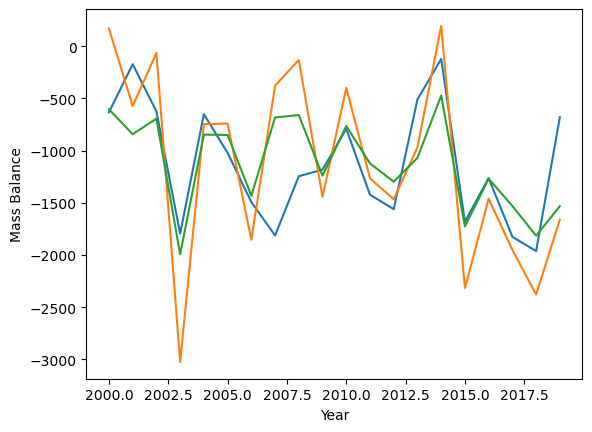

In [80]:
# Firstly get the observed mass balance for comparison from the data set - from the WGMS data set
mbdf['ref_mb'] = gdir_hef.get_ref_mb_data()[['ANNUAL_BALANCE']]

# Now compute the "fixed geometry" MB from OGGM that has been calibrated to the 
mbmod = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_mf'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=mbdf.index)


# Trying the approach of calibrating one parameter at a time, with a cost function considering mean and std
mbdf['mod_mb_mf'].mean() # This is close to the actual mean and passes the calibration

# Call the test_wgms function
res_df = mb_calibration_with_mean_and_std(gdir_hef,
          ref_mb=mod_mb.mean(),
          std_mb=mod_mb.std(),
          ref_mb_years=mbdf.index.values,
          overwrite_gdir=True,
          mb_model_class=MonthlyTIModel,
          calibrate_param1='prcp_fac',
          calibrate_param2='melt_f',
          calibrate_param3='temp_bias',
          melt_f_min=1.5,
          melt_f_max=17.0,
          temp_bias_min=-15.0,
          temp_bias_max=15.0,
          prcp_fac_min=0.1,
          prcp_fac_max=10.0,
          write_to_gdir=True)

mbmod = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_pf'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=mbdf.index)


mbdf['ref_mb'].plot();
mbdf['mod_mb_mf'].plot();
mbdf['mod_mb_pf'].plot();
plt.xlabel("Year"); plt.ylabel("Mass Balance");



We can see above that not all parameters are calibrated depending on if the mean mass balance can be matched appropriately. 

Calibrating these in different orders give different results.

Now calibrating with all parameters to the mean and standard deviation, in the previous calibration we have guessed the weighting ourselves. As we want to match the mean as closely as possible, this is weighted much more than the standard deviation.

# Now calibrate using a function that can optimise the weighting between mean and std and calibrate all parameters at once

In [ ]:

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize as moo_minimize
from pymoo.termination import get_termination
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.population import Population
from pymoo.core.individual import Individual
from scipy.stats import qmc
import numpy as np

cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]
observed_mb_series = gdir_hef.get_ref_mb_data()['ANNUAL_BALANCE'].loc[2000:2019]

# Step 1: Generate Sobol Samples
# Setting the bounds of the parameter values (currently from the boundaries)
param_bounds = [(cfg.PARAMS['melt_f_min'], cfg.PARAMS['melt_f_max']),
                (cfg.PARAMS['prcp_fac_min'], cfg.PARAMS['prcp_fac_max']),
                (cfg.PARAMS['temp_bias_min'], cfg.PARAMS['temp_bias_max'])]

n_samples = 50 # How many initial samples we take from the space for the optimisation
sampler = qmc.Sobol(d=len(param_bounds), scramble=True) # Setting the sampling technique
sobol_samples = sampler.random_base2(m=int(np.log2(n_samples)))# Executing the samples
scaled_samples = qmc.scale(sobol_samples,
                           [b[0] for b in param_bounds],
                           [b[1] for b in param_bounds]) # Ensuring the samples are within our bounds

# Step 2: Convert Sobol samples to pymoo Population
initial_pop = Population.new("X", scaled_samples)

# Step 3: Define the multi-objective problem
class MBProblem(ElementwiseProblem):
    def __init__(self, gdir, observed_mb_series):
        super().__init__(n_var=3, n_obj=2, xl=[b[0] for b in param_bounds], xu=[b[1] for b in param_bounds]) 
        self.gdir = gdir # Select the desired glacier directory
        self.observed_mb_series = observed_mb_series # The observed MB

    def _evaluate(self, x, out, *args, **kwargs):
        melt_f, prcp_fac, temp_bias = x # Setting the parameters we will be evaluating in this run
        mbmod = massbalance.MonthlyTIModel(self.gdir, # Running the simulation with the set parameters
                                           melt_f=melt_f,
                                           prcp_fac=prcp_fac,
                                           temp_bias=temp_bias,
                                           check_calib_params=False) 
        
        # Calculate the mass balance with the new parameters
        simulated_series = mbmod.get_specific_mb(
            fls=self.gdir.read_pickle('inversion_flowlines'),
            year=self.observed_mb_series.index.values
        )

        # Calculate the absolute error for the mean and standard devation
        mean_error = abs(simulated_series.mean() - self.observed_mb_series.mean())
        std_error = abs(simulated_series.std() - self.observed_mb_series.std())

        print("Observed MB range:", observed_mb_series.min(), observed_mb_series.max())
        print("Simulated MB range:", simulated_series.min(), simulated_series.max())
        # Set the output of the function
        out["F"] = [mean_error, std_error]

# Step 4: Run NSGA-II with Sobol initial population
problem = MBProblem(gdir_hef, observed_mb_series) # Setting the problem set in the class above
algorithm = NSGA2(pop_size=n_samples) # Now setting the algorithm we will be using with a number of n_samples
termination = get_termination("n_gen", 100) # Termination conditions

# The minimization using Pymoo
res = moo_minimize(problem, algorithm, termination, seed=1, verbose=True, X=scaled_samples)

# Step 5: Extract Pareto front
pareto_solutions = res.F
pareto_params = res.X

print("Pareto front solutions:")
for i in range(len(pareto_solutions)):
    print(f"Params={pareto_params[i]}, Objectives={pareto_solutions[i]}")


2025-11-20 17:12:37: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-20 17:12:37: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


Observed MB range: -1963.0 -122.0
Simulated MB range: 4455.236438264039 7350.338700117977
Observed MB range: -1963.0 -122.0
Simulated MB range: 956.7499726853298 1578.4653515057776
Observed MB range: -1963.0 -122.0
Simulated MB range: 1100.8872631763113 3219.1896710736405
Observed MB range: -1963.0 -122.0
Simulated MB range: -13354.756942137825 -8800.57153965871
Observed MB range: -1963.0 -122.0
Simulated MB range: 5417.695807106173 8938.223528256967
Observed MB range: -1963.0 -122.0
Simulated MB range: -7015.026951268226 -3013.3792012520994
Observed MB range: -1963.0 -122.0
Simulated MB range: -8093.865132808578 -6216.234304850018
Observed MB range: -1963.0 -122.0
Simulated MB range: -24606.26360044613 -16848.591702399983
Observed MB range: -1963.0 -122.0
Simulated MB range: 5518.271985122761 9104.156130000842
Observed MB range: -1963.0 -122.0
Simulated MB range: -6113.579641578806 -4840.774132795238
Observed MB range: -1963.0 -122.0
Simulated MB range: -11424.17548218704 -9155.424994

Plotting the calculated mass balances calculated

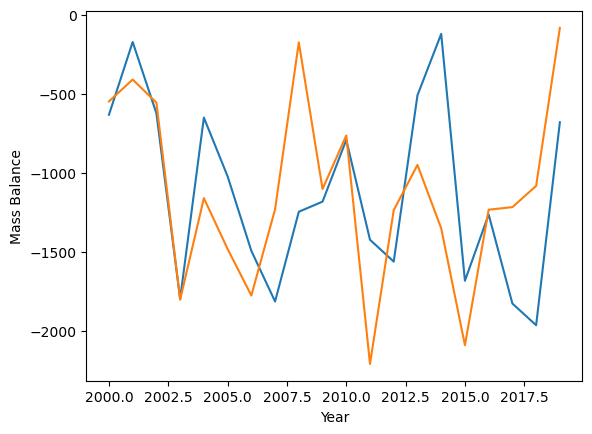

In [88]:
# Firstly get the observed mass balance for comparison from the data set - from the WGMS data set
mbdf['ref_mb'] = gdir_hef.get_ref_mb_data()['ANNUAL_BALANCE']

for i in range(len(pareto_solutions)):
    # Store the parameters
    df = gdir_hef.read_json('mb_calib', allow_empty=True)
    df['bias'] = 0
    df['melt_f'] = pareto_params[i][0]
    df['prcp_fac'] = pareto_params[i][1]
    df['temp_bias'] = pareto_params[i][2]
    # What did we try to match?
    df['reference_mb'] = mbdf['ANNUAL_BALANCE'].mean()
    gdir_hef.write_json(df, 'mb_calib', filesuffix='')
    # Now compute the "fixed geometry" MB from OGGM that has been calibrated to the 
    mbmod = massbalance.MonthlyTIModel(gdir_hef)
    mbdf['mod_mb_' + str(i)] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=mbdf.index)

mbdf['ref_mb'].plot();
mbdf['mod_mb_0'].plot();
plt.xlabel("Year"); plt.ylabel("Mass Balance");

Now plot the pareto front for the best values found:

[[6.07914982e-02 5.57146281e-01]
 [1.30605858e-02 6.12510255e-01]
 [8.04548447e-03 1.41063073e+00]
 [1.36371821e-01 5.06248487e-01]
 [3.56041483e-02 5.59467821e-01]
 [7.42540992e-01 4.02168935e-03]
 [3.83385649e-01 6.82188485e-02]
 [5.81955368e-04 4.15655792e+01]
 [2.06239482e-01 8.72996378e-02]
 [8.28912260e-01 3.57879773e-04]
 [7.98972980e-01 1.24123988e-03]]


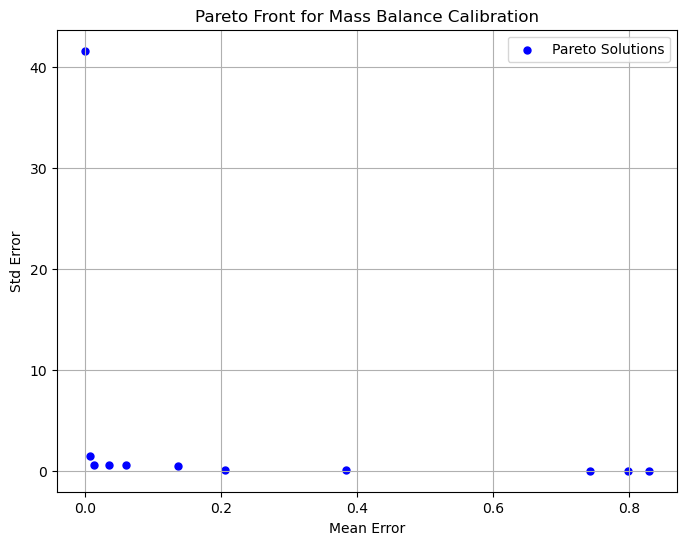

[[6.07914982e-02 5.57146281e-01]
 [1.30605858e-02 6.12510255e-01]
 [8.04548447e-03 1.41063073e+00]
 [1.36371821e-01 5.06248487e-01]
 [3.56041483e-02 5.59467821e-01]
 [7.42540992e-01 4.02168935e-03]
 [3.83385649e-01 6.82188485e-02]
 [5.81955368e-04 4.15655792e+01]
 [2.06239482e-01 8.72996378e-02]
 [8.28912260e-01 3.57879773e-04]
 [7.98972980e-01 1.24123988e-03]]


In [84]:
import matplotlib.pyplot as plt

# Extract objectives
F = list(res.F)  # shape (n_points, 2) because you have 2 objectives
X = list(res.X)  # shape (n_points, 3) for your parameters

# Removing one where the std error was around 40 this is quite large? But this does minimise the mean error
# del F[7] 
# del X[7]

F = np.array(F)
X = np.array(X)

print(F)

# Plot Pareto front
plt.figure(figsize=(8, 6))
plt.scatter(F[:, 0], F[:, 1], c='blue', s=25, label='Pareto Solutions')
plt.xlabel('Mean Error')
plt.ylabel('Std Error')
plt.title('Pareto Front for Mass Balance Calibration')
plt.grid(True)
plt.legend()
plt.show()

print(F)


# Running a diagnostic to calibrate all glaciers in our directory and storing the difference in the calculated errors.

In [103]:
from oggm.utils._funcs import rmsd

mean_error = []
std_error = []
rmsd_error = []

for i in range(len(pareto_solutions)):
    mean_diff = mbdf['mod_mb_' + str(i)].mean() - mbdf['ref_mb'].mean()
    mean_error.append(mean_diff)
    # print(f"Solution {i}: Mean Difference = {mean_diff}")

print("The average mean difference across the solution", np.mean(mean_error)) # The average mean difference across the solution is 0.2

for i in range(len(pareto_solutions)):
    std_diff = mbdf['mod_mb_' + str(i)].std() - mbdf['ref_mb'].std()
    std_error.append(std_diff)
    # print(f"Solution {i}: Mean Difference = {std_diff}")

print("The average std difference across the solution", np.mean(std_error)) # The average std is around 14.0

# We didn't minimise the rmsd but lets see if it has minimised the rmsd at all
for i in range(len(pareto_solutions)):
    rmsd_diff = rmsd(mbdf['mod_mb_' + str(i)], mbdf['ref_mb'])
    rmsd_error.append(rmsd_diff)
    # print(f"Solution {i}: RMSD = {rmsd_diff}")

print("The average rmsd error across the solution", np.mean(rmsd_error)) # The average rmsd error is around 555, which is really quite large here.

The average mean difference across the solution 0.2498007282574897
The average std difference across the solution 10.61669141829815
The average rmsd error across the solution 555.3094556034847


# IGNORE FOR NOW

Now calibrating the prcp_fac to the RMSE, then calibrating melt_f and temp_bias to the mean:

In [78]:
from oggm.core.massbalance import mb_calibration_from_scalar_mb
from oggm.core.massbalance import MonthlyTIModel

mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

scalar_df = mb_calibration_from_scalar_mb(gdir_hef,
                            ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
                            ref_period=None,
                            overwrite_gdir=True,
                            mb_model_class=MonthlyTIModel,
                            calibrate_param1='prcp_fac',
                            calibrate_param2='melt_f',
                            calibrate_param3='temp_bias',
                            melt_f_min=1.5,
                            melt_f_max=17.0,
                            temp_bias_min=-15.0,
                            temp_bias_max=15.0,
                            prcp_fac_min=0.1,
                            prcp_fac_max=10.0,
                            write_to_gdir=True)

scalar_df


2025-11-20 17:11:56: oggm.core.massbalance: InvalidParamsError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: One of `ref_mb_years` or `ref_period` is required for calibration.


InvalidParamsError: One of `ref_mb_years` or `ref_period` is required for calibration.

In [ ]:
from oggm.core.massbalance import MonthlyTIModel, calving_mb, decide_winter_precip_factor
from oggm.exceptions import InvalidParamsError, InvalidWorkflowError
from oggm.utils._funcs import rmsd
from scipy import optimize
import xarray as xr

# Climate relevant global params - not optimised
MB_GLOBAL_PARAMS = ['temp_default_gradient',
                    'temp_all_solid',
                    'temp_all_liq',
                    'temp_melt']


def mb_calibration_from_scalar_mb(gdir, *,
                                  ref_mb=None,
                                  ref_mb_err=None,
                                  ref_period=None,
                                  ref_mb_years=None,
                                  write_to_gdir=True,
                                  overwrite_gdir=False,
                                  use_2d_mb=False,
                                  calibrate_param1='melt_f',
                                  calibrate_param2=None,
                                  calibrate_param3=None,
                                  melt_f=None,
                                  melt_f_min=None,
                                  melt_f_max=None,
                                  prcp_fac=None,
                                  prcp_fac_min=None,
                                  prcp_fac_max=None,
                                  temp_bias=None,
                                  temp_bias_min=None,
                                  temp_bias_max=None,
                                  mb_model_class=MonthlyTIModel,
                                  filesuffix='',
                                  ):
    """Determine the mass balance parameters from a scalar mass-balance value.

    This calibrates the mass balance parameters using a reference average
    MB data over a given period (e.g. average in-situ SMB or geodetic MB).
    This flexible calibration allows to calibrate three parameters one after
    another. The first parameter is varied between two chosen values (a range)
    until the ref MB value is matched. If this fails, the second parameter
    can be changed, etc.

    This can be used for example to apply the "three-step calibration"
    introduced by Huss & Hock 2015, but you can choose any order of
    calibration.

    This task can be called by other, "higher level" tasks, for example
    :py:func:`oggm.core.massbalance.mb_calibration_from_geodetic_mb` or
    :py:func:`oggm.core.massbalance.mb_calibration_from_wgms_mb`.

    Note that this does not compute the apparent mass balance at
    the same time - users need to run `apparent_mb_from_any_mb after`
    calibration.

    Parameters
    ----------
    gdir : :py:class:`oggm.GlacierDirectory`
        the glacier directory to calibrate
    ref_mb : float, required
        the reference mass balance to match (units: kg m-2 yr-1)
        It is required here - if you want to use available observations,
        use :py:func:`oggm.core.massbalance.mb_calibration_from_geodetic_mb`
        or :py:func:`oggm.core.massbalance.mb_calibration_from_wgms_mb`.
    ref_mb_err : float, optional
        currently only used for logging - it is not used in the calibration.
    ref_period : str, optional
        date format - for example '2000-01-01_2010-01-01'. If this is not
        set, ref_mb_years needs to be set.
    ref_mb_years : tuple of length 2 (range) or list of years.
        convenience kwarg to override ref_period. If a tuple of length 2 is
        given, all years between this range (excluding the last one) are used.
        If a list  of years is given, all these will be used (useful for
        data with gaps)
    write_to_gdir : bool
        whether to write the results of the calibration to the glacier
        directory. If True (the default), this will be saved as `mb_calib.json`
        and be used by the MassBalanceModel class as parameters in subsequent
        tasks.
    overwrite_gdir : bool
        if a `mb_calib.json` exists, this task won't overwrite it per default.
        Set this to True to enforce overwriting (i.e. with consequences for the
        future workflow).
    use_2d_mb : bool
        Set to True if the mass balance calibration has to be done of the 2D mask
        of the glacier (for fully distributed runs only).
    mb_model_class : MassBalanceModel class
        the MassBalanceModel to use for the calibration. Needs to use the
        same parameters as MonthlyTIModel (the default): melt_f,
        temp_bias, prcp_fac.
    calibrate_param1 : str
        in the three-step calibration, the name of the first parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac').
    calibrate_param2 : str
        in the three-step calibration, the name of the second parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac'). If not
        set and the algorithm cannot match observations, it will raise an
        error.
    calibrate_param3 : str
        in the three-step calibration, the name of the third parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac'). If not
        set and the algorithm cannot match observations, it will raise an
        error.
    melt_f: float
        the default value to use as melt factor (or the starting value when
        optimizing MB). Defaults to cfg.PARAMS['melt_f'].
    melt_f_min: float
        the minimum accepted value for the melt factor during optimisation.
        Defaults to cfg.PARAMS['melt_f_min'].
    melt_f_max: float
        the maximum accepted value for the melt factor during optimisation.
        Defaults to cfg.PARAMS['melt_f_max'].
    prcp_fac: float
        the default value to use as precipitation scaling factor
        (or the starting value when optimizing MB). Defaults to the method
        chosen in `params.cfg` (winter prcp or global factor).
    prcp_fac_min: float
        the minimum accepted value for the precipitation scaling factor during
        optimisation. Defaults to cfg.PARAMS['prcp_fac_min'].
    prcp_fac_max: float
        the maximum accepted value for the precipitation scaling factor during
        optimisation. Defaults to cfg.PARAMS['prcp_fac_max'].
    temp_bias: float
        the default value to use as temperature bias (or the starting value when
        optimizing MB). Defaults to 0.
    temp_bias_min: float
        the minimum accepted value for the temperature bias during optimisation.
        Defaults to cfg.PARAMS['temp_bias_min'].
    temp_bias_max: float
        the maximum accepted value for the temperature bias during optimisation.
        Defaults to cfg.PARAMS['temp_bias_max'].
    filesuffix: str
        add a filesuffix to mb_calib.json. This could be useful for sensitivity
        analyses with MB models, if they need to fetch other sets of params for
        example.
    """

    # Param constraints
    if melt_f_min is None:
        melt_f_min = cfg.PARAMS['melt_f_min']
    if melt_f_max is None:
        melt_f_max = cfg.PARAMS['melt_f_max']
    if prcp_fac_min is None:
        prcp_fac_min = cfg.PARAMS['prcp_fac_min']
    if prcp_fac_max is None:
        prcp_fac_max = cfg.PARAMS['prcp_fac_max']
    if temp_bias_min is None:
        temp_bias_min = cfg.PARAMS['temp_bias_min']
    if temp_bias_max is None:
        temp_bias_max = cfg.PARAMS['temp_bias_max']
    if ref_mb_years is not None and ref_period is not None:
        raise InvalidParamsError('Cannot set `ref_mb_years` and `ref_period` '
                                 'at the same time.')

    if not use_2d_mb:
        fls = gdir.read_pickle('inversion_flowlines')
    else:
        # if the 2D data is used, the flowline is not needed.
        fls = None
        # get the 2D data
        fp = gdir.get_filepath('gridded_data')
        with xr.open_dataset(fp) as ds:
            # 'topo' instead of 'topo_smoothed'?
            heights = ds.topo_smoothed.data[ds.glacier_mask.data == 1]
            widths = np.ones(len(heights))

    # Let's go
    # Climate period
    if ref_mb_years is not None:
        if len(ref_mb_years) > 2:
            years = np.asarray(ref_mb_years)
            ref_period = 'custom'
        else:
            years = np.arange(*ref_mb_years)
            ref_period = f'{ref_mb_years[0]}-01-01_{ref_mb_years[1]}-01-01'
    elif ref_period is not None:
        y0, y1 = ref_period.split('_')
        y0 = int(y0.split('-')[0])
        y1 = int(y1.split('-')[0])
        years = np.arange(y0, y1)
    else:
        raise InvalidParamsError('One of `ref_mb_years` or `ref_period` '
                                 'is required for calibration.')

    # Do we have a calving glacier?
    cmb = calving_mb(gdir)
    if cmb != 0:
        raise NotImplementedError('Calving with geodetic MB is not implemented '
                                  'yet, but it should actually work. Well keep '
                                  'you posted!')

    # Ok, regardless on how we want to calibrate, we start with defaults
    if melt_f is None:
        melt_f = cfg.PARAMS['melt_f']

    if prcp_fac is None:
        if cfg.PARAMS['use_winter_prcp_fac']:
            # Some sanity check
            if cfg.PARAMS['prcp_fac'] is not None:
                raise InvalidWorkflowError("Set PARAMS['prcp_fac'] to None "
                                           "if using PARAMS['winter_prcp_factor'].")
            prcp_fac = decide_winter_precip_factor(gdir)
        else:
            prcp_fac = cfg.PARAMS['prcp_fac']
            if prcp_fac is None:
                raise InvalidWorkflowError("Set either PARAMS['use_winter_prcp_fac'] "
                                           "or PARAMS['winter_prcp_factor'].")

    if temp_bias is None:
        temp_bias = 0

    # Create the MB model we will calibrate
    mb_mod = mb_model_class(gdir,
                            melt_f=melt_f,
                            temp_bias=temp_bias,
                            prcp_fac=prcp_fac,
                            check_calib_params=False)

    # Check that the years are available
    for y in years:
        if not mb_mod.is_year_valid(y):
            raise ValueError(f'year {y} out of the valid time bounds: '
                             f'[{mb_mod.ys}, {mb_mod.ye}]')

    if calibrate_param1 == 'melt_f':
        min_range, max_range = melt_f_min, melt_f_max
    elif calibrate_param1 == 'prcp_fac':
        min_range, max_range = prcp_fac_min, prcp_fac_max
    elif calibrate_param1 == 'temp_bias':
        min_range, max_range = temp_bias_min, temp_bias_max
    else:
        raise InvalidParamsError("calibrate_param1 must be one of "
                                 "['melt_f', 'prcp_fac', 'temp_bias']")

    def to_minimize(x, model_attr):
        # Set the new attr value
        setattr(mb_mod, model_attr, x)
        if use_2d_mb:
            out = mb_mod.get_specific_mb(heights=heights, widths=widths, year=years).mean()
        else:
            out = mb_mod.get_specific_mb(fls=fls, year=years).mean()
        return np.mean(out - ref_mb)

    try:
        optim_param1 = optimize.brentq(to_minimize,
                                       min_range, max_range,
                                       args=(calibrate_param1,)
                                       )
    except ValueError:
        if not calibrate_param2:
            raise RuntimeError(f'{gdir.rgi_id}: ref mb not matched. '
                               f'Try to set calibrate_param2.')

        # Check which direction we need to go
        diff_1 = to_minimize(min_range, calibrate_param1)
        diff_2 = to_minimize(max_range, calibrate_param1)
        optim_param1 = min_range if abs(diff_1) < abs(diff_2) else max_range
        setattr(mb_mod, calibrate_param1, optim_param1)

        # Second step
        if calibrate_param2 == 'melt_f':
            min_range, max_range = melt_f_min, melt_f_max
        elif calibrate_param2 == 'prcp_fac':
            min_range, max_range = prcp_fac_min, prcp_fac_max
        elif calibrate_param2 == 'temp_bias':
            min_range, max_range = temp_bias_min, temp_bias_max
        else:
            raise InvalidParamsError("calibrate_param2 must be one of "
                                     "['melt_f', 'prcp_fac', 'temp_bias']")
        try:
            optim_param2 = optimize.brentq(to_minimize,
                                           min_range, max_range,
                                           args=(calibrate_param2,)
                                           )
        except ValueError:
            # Third step
            if not calibrate_param3:
                raise RuntimeError(f'{gdir.rgi_id}: ref mb not matched. '
                                   f'Try to set calibrate_param3.')

            # Check which direction we need to go
            diff_1 = to_minimize(min_range, calibrate_param2)
            diff_2 = to_minimize(max_range, calibrate_param2)
            optim_param2 = min_range if abs(diff_1) < abs(diff_2) else max_range
            setattr(mb_mod, calibrate_param2, optim_param2)

            # Third step
            if calibrate_param3 == 'melt_f':
                min_range, max_range = melt_f_min, melt_f_max
            elif calibrate_param3 == 'prcp_fac':
                min_range, max_range = prcp_fac_min, prcp_fac_max
            elif calibrate_param3 == 'temp_bias':
                min_range, max_range = temp_bias_min, temp_bias_max
            else:
                raise InvalidParamsError("calibrate_param3 must be one of "
                                         "['melt_f', 'prcp_fac', 'temp_bias']")
            try:
                optim_param3 = optimize.brentq(to_minimize,
                                               min_range, max_range,
                                               args=(calibrate_param3,)
                                               )
            except ValueError:
                raise RuntimeError(f'{gdir.rgi_id}: we tried very hard but we '
                                   f'could not find a combination of '
                                   f'parameters that works for this ref mb.')

            if calibrate_param3 == 'melt_f':
                melt_f = optim_param3
            elif calibrate_param3 == 'prcp_fac':
                prcp_fac = optim_param3
            elif calibrate_param3 == 'temp_bias':
                temp_bias = optim_param3

        if calibrate_param2 == 'melt_f':
            melt_f = optim_param2
        elif calibrate_param2 == 'prcp_fac':
            prcp_fac = optim_param2
        elif calibrate_param2 == 'temp_bias':
            temp_bias = optim_param2

    if calibrate_param1 == 'melt_f':
        melt_f = optim_param1
    elif calibrate_param1 == 'prcp_fac':
        prcp_fac = optim_param1
    elif calibrate_param1 == 'temp_bias':
        temp_bias = optim_param1

    # Store parameters
    df = gdir.read_json('mb_calib', allow_empty=True)
    df['rgi_id'] = gdir.rgi_id
    df['bias'] = 0
    df['melt_f'] = melt_f
    df['prcp_fac'] = prcp_fac
    df['temp_bias'] = temp_bias
    # What did we try to match?
    df['reference_mb'] = ref_mb
    df['reference_mb_err'] = ref_mb_err
    df['reference_period'] = ref_period

    # Add the climate related params to the GlacierDir to make sure
    # other tools cannot fool around without re-calibration
    df['mb_global_params'] = {k: cfg.PARAMS[k] for k in MB_GLOBAL_PARAMS}
    df['baseline_climate_source'] = gdir.get_climate_info()['baseline_climate_source']
    # Write
    if write_to_gdir:
        if gdir.has_file('mb_calib', filesuffix=filesuffix) and not overwrite_gdir:
            raise InvalidWorkflowError('`mb_calib.json` already exists for '
                                       'this repository. Set `overwrite_gdir` '
                                       'to True if you want to overwrite '
                                       'a previous calibration.')
        gdir.write_json(df, 'mb_calib', filesuffix=filesuffix)
    return df



mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

scalar_df = mb_calibration_from_scalar_mb(gdir_hef,
                            ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
                            ref_mb_years=mbdf.index.values,
                            ref_period=None,
                            overwrite_gdir=True,
                            mb_model_class=MonthlyTIModel,
                            calibrate_param1='prcp_fac',
                            calibrate_param2='melt_f',
                            calibrate_param3='temp_bias',
                            melt_f_min=1.5,
                            melt_f_max=17.0,
                            temp_bias_min=-15.0,
                            temp_bias_max=15.0,
                            prcp_fac_min=0.1,
                            prcp_fac_max=10.0,
                            write_to_gdir=True)

scalar_df

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 0.9783635516648428,
 'temp_bias': 0,
 'reference_mb': -1122.75,
 'reference_mb_err': None,
 'reference_period': 'custom',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

So above we have calibrated the precipitation factor first, then the melt factor and then the temperature bias. This is all calibrated to the minimise the differences between the simulated mean and reference mean annual mass balance.

<Axes: xlabel='YEAR'>

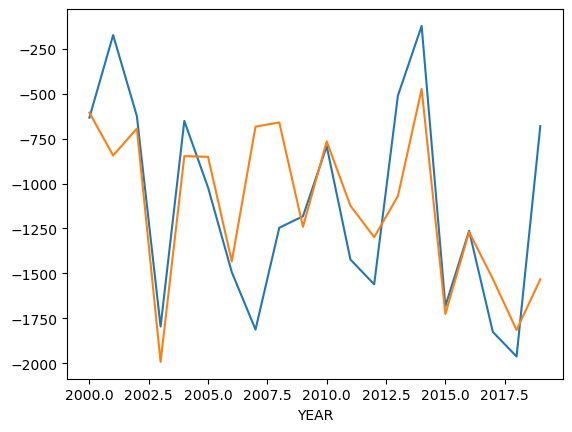

In [ ]:
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
mbmod = massbalance.MonthlyTIModel(gdir_hef, # Running the simulation with the set parameters
                                           melt_f=scalar_df['melt_f'],
                                           prcp_fac=scalar_df['prcp_fac'],
                                           temp_bias=scalar_df['temp_bias'],
                                           check_calib_params=False) 
        

mbdf['mod_mb_0'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=mbdf.index)

mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf['in_situ_mb'].plot()
mbdf['mod_mb_0'].plot()

# The results showing the calibration of prcp_fac with the rsmd minimization and then considering calibrating the last two parameters to match the mean MB

# Calibration with the RMSD and the mean

(mentioned by Fabien on Monday)

Now we will update the scalar calibration technique to calibrate with the RMSD and the mean.

We can see in the mass balance calibration tutorial that the precipitation factor, when calibrated has a huge impact on the fit of the mass balance.

Therefore we will firstly calibrate the precipitation factor to the RMSD, to minimise the error in the datasets. Then we will calibrate the remaining two parameters to minimise the mean.

### Investigating how to calibrate with RMSD

I noticed when calibrating initially that brentq was not converging as it requires a change in sign for the function. For our bounds of prcp_fac when investigating, there is actually no change in sign for this function. It gets very close to zero but never quite reaches it.

The investigation below shows this and that we can actually minimise the rmsd to be much smaller.

Text(0, 0.5, 'RMSD')

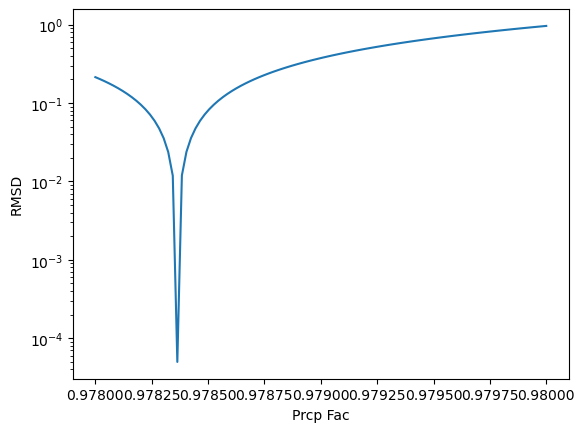

In [ ]:
ref_mb=mbdf['ANNUAL_BALANCE'].mean()
years=mbdf.index.values
melt_f=cfg.PARAMS['melt_f']
prcp_fac=cfg.PARAMS['prcp_fac']
temp_bias=0
fls = gdir_hef.read_pickle('inversion_flowlines')


mb_mod = MonthlyTIModel(gdir_hef,
                            melt_f=melt_f,
                            temp_bias=temp_bias,
                            prcp_fac=prcp_fac,
                            check_calib_params=False)

def rmsd_cost_function(x, model_attr):
    # Set the new attr value
    setattr(mb_mod, model_attr, x)
    mean_out = mb_mod.get_specific_mb(fls=fls, year=years).mean()
    return rmsd(ref_mb, mean_out)

diff = []
index =[]

for pf in np.linspace(0.1, 10, 1000):
    index.append(pf)
    diff.append(rmsd_cost_function(pf, 'prcp_fac'))

plt.plot(index, diff)
plt.yscale('log')
plt.xlabel('Prcp Fac')
plt.ylabel('RMSD')  

diff = []
index =[]

for pf in np.linspace(0.978, 0.98, 100):
    index.append(pf)
    diff.append(rmsd_cost_function(pf, 'prcp_fac'))

plt.cla()
plt.plot(index, diff)
plt.yscale('log')
plt.xlabel('Prcp Fac')
plt.ylabel('RMSD')  

Since the boundary is never crossed we cannot use a minimization method such as brentq as this expects a change in sign. I will instead use Newton which just requires an intial point.

This is not a guaranteed convergence like brentq, but this is a quick method to try for now.

**TODO: Here the RMSD is very large, I think this is due to unprecidented years in the glacier, so I'm not sure (at least for this glacier is going to be beneficial?)**

In [ ]:
from oggm.core.massbalance import MonthlyTIModel, calving_mb, decide_winter_precip_factor
from oggm.exceptions import InvalidParamsError, InvalidWorkflowError
from oggm.utils._funcs import rmsd
from scipy import optimize
import xarray as xr

# Climate relevant global params - not optimised
MB_GLOBAL_PARAMS = ['temp_default_gradient',
                    'temp_all_solid',
                    'temp_all_liq',
                    'temp_melt']

# Using std and mean to calibrate here
def mb_calibration_from_wgms_mb(gdir, *,
                                  ref_mb=None,
                                  write_to_gdir=True,
                                  overwrite_gdir=False,
                                  use_2d_mb=False,
                                  calibrate_params=('melt_f',),
                                  melt_f=None,
                                  melt_f_min=None,
                                  melt_f_max=None,
                                  prcp_fac=None,
                                  prcp_fac_min=None,
                                  prcp_fac_max=None,
                                  temp_bias=None,
                                  temp_bias_min=None,
                                  temp_bias_max=None,
                                  mb_model_class=MonthlyTIModel,
                                  filesuffix='',
                                  ):
    """Determine the mass balance parameters from a scalar mass-balance value.

    This calibrates the mass balance parameters using a reference average
    MB data over a given period (e.g. average in-situ SMB or geodetic MB).
    This flexible calibration allows to calibrate three parameters one after
    another. The first parameter is varied between two chosen values (a range)
    until the ref MB value is matched. If this fails, the second parameter
    can be changed, etc.

    This can be used for example to apply the "three-step calibration"
    introduced by Huss & Hock 2015, but you can choose any order of
    calibration.

    This task can be called by other, "higher level" tasks, for example
    :py:func:`oggm.core.massbalance.mb_calibration_from_geodetic_mb` or
    :py:func:`oggm.core.massbalance.mb_calibration_from_wgms_mb`.

    Note that this does not compute the apparent mass balance at
    the same time - users need to run `apparent_mb_from_any_mb after`
    calibration.

    Parameters
    ----------
    gdir : :py:class:`oggm.GlacierDirectory`
        the glacier directory to calibrate
    ref_mb : float, required
        the reference mass balance to match (units: kg m-2 yr-1)
        It is required here - if you want to use available observations,
        use :py:func:`oggm.core.massbalance.mb_calibration_from_geodetic_mb`
        or :py:func:`oggm.core.massbalance.mb_calibration_from_wgms_mb`.
    ref_mb_err : float, optional
        currently only used for logging - it is not used in the calibration.
    ref_period : str, optional
        date format - for example '2000-01-01_2010-01-01'. If this is not
        set, ref_mb_years needs to be set.
    ref_mb_years : tuple of length 2 (range) or list of years.
        convenience kwarg to override ref_period. If a tuple of length 2 is
        given, all years between this range (excluding the last one) are used.
        If a list  of years is given, all these will be used (useful for
        data with gaps)
    write_to_gdir : bool
        whether to write the results of the calibration to the glacier
        directory. If True (the default), this will be saved as `mb_calib.json`
        and be used by the MassBalanceModel class as parameters in subsequent
        tasks.
    overwrite_gdir : bool
        if a `mb_calib.json` exists, this task won't overwrite it per default.
        Set this to True to enforce overwriting (i.e. with consequences for the
        future workflow).
    use_2d_mb : bool
        Set to True if the mass balance calibration has to be done of the 2D mask
        of the glacier (for fully distributed runs only).
    mb_model_class : MassBalanceModel class
        the MassBalanceModel to use for the calibration. Needs to use the
        same parameters as MonthlyTIModel (the default): melt_f,
        temp_bias, prcp_fac.
    calibrate_param1 : str
        in the three-step calibration, the name of the first parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac').
    calibrate_param2 : str
        in the three-step calibration, the name of the second parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac'). If not
        set and the algorithm cannot match observations, it will raise an
        error.
    calibrate_param3 : str
        in the three-step calibration, the name of the third parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac'). If not
        set and the algorithm cannot match observations, it will raise an
        error.
    melt_f: float
        the default value to use as melt factor (or the starting value when
        optimizing MB). Defaults to cfg.PARAMS['melt_f'].
    melt_f_min: float
        the minimum accepted value for the melt factor during optimisation.
        Defaults to cfg.PARAMS['melt_f_min'].
    melt_f_max: float
        the maximum accepted value for the melt factor during optimisation.
        Defaults to cfg.PARAMS['melt_f_max'].
    prcp_fac: float
        the default value to use as precipitation scaling factor
        (or the starting value when optimizing MB). Defaults to the method
        chosen in `params.cfg` (winter prcp or global factor).
    prcp_fac_min: float
        the minimum accepted value for the precipitation scaling factor during
        optimisation. Defaults to cfg.PARAMS['prcp_fac_min'].
    prcp_fac_max: float
        the maximum accepted value for the precipitation scaling factor during
        optimisation. Defaults to cfg.PARAMS['prcp_fac_max'].
    temp_bias: float
        the default value to use as temperature bias (or the starting value when
        optimizing MB). Defaults to 0.
    temp_bias_min: float
        the minimum accepted value for the temperature bias during optimisation.
        Defaults to cfg.PARAMS['temp_bias_min'].
    temp_bias_max: float
        the maximum accepted value for the temperature bias during optimisation.
        Defaults to cfg.PARAMS['temp_bias_max'].
    filesuffix: str
        add a filesuffix to mb_calib.json. This could be useful for sensitivity
        analyses with MB models, if they need to fetch other sets of params for
        example.
    """

    # Param constraints
    if melt_f_min is None:
        melt_f_min = cfg.PARAMS['melt_f_min']
    if melt_f_max is None:
        melt_f_max = cfg.PARAMS['melt_f_max']
    if prcp_fac_min is None:
        prcp_fac_min = cfg.PARAMS['prcp_fac_min']
    if prcp_fac_max is None:
        prcp_fac_max = cfg.PARAMS['prcp_fac_max']
    if temp_bias_min is None:
        temp_bias_min = cfg.PARAMS['temp_bias_min']
    if temp_bias_max is None:
        temp_bias_max = cfg.PARAMS['temp_bias_max']

    if not use_2d_mb:
        fls = gdir.read_pickle('inversion_flowlines')
    else:
        # if the 2D data is used, the flowline is not needed.
        fls = None
        # get the 2D data
        fp = gdir.get_filepath('gridded_data')
        with xr.open_dataset(fp) as ds:
            # 'topo' instead of 'topo_smoothed'?
            heights = ds.topo_smoothed.data[ds.glacier_mask.data == 1]
            widths = np.ones(len(heights))

    # Climate period
    ref_mb_years = ref_mb.index.values
    print(ref_mb_years)
    
    # Do we have a calving glacier?
    cmb = calving_mb(gdir)
    if cmb != 0:
        raise NotImplementedError('Calving with geodetic MB is not implemented '
                                  'yet, but it should actually work. Well keep '
                                  'you posted!')

    # Ok, regardless on how we want to calibrate, we start with defaults
    if melt_f is None:
        melt_f = cfg.PARAMS['melt_f']

    if prcp_fac is None:
        if cfg.PARAMS['use_winter_prcp_fac']:
            # Some sanity check
            if cfg.PARAMS['prcp_fac'] is not None:
                raise InvalidWorkflowError("Set PARAMS['prcp_fac'] to None "
                                           "if using PARAMS['winter_prcp_factor'].")
            prcp_fac = decide_winter_precip_factor(gdir)
        else:
            prcp_fac = cfg.PARAMS['prcp_fac']
            if prcp_fac is None:
                raise InvalidWorkflowError("Set either PARAMS['use_winter_prcp_fac'] "
                                           "or PARAMS['winter_prcp_factor'].")

    if temp_bias is None:
        temp_bias = 0

    # Create the MB model we will calibrate
    mb_mod = mb_model_class(gdir,
                            melt_f=melt_f,
                            temp_bias=temp_bias,
                            prcp_fac=prcp_fac,
                            check_calib_params=False)

    # Check that the years are available
    for y in years:
        if not mb_mod.is_year_valid(y):
            raise ValueError(f'year {y} out of the valid time bounds: '
                             f'[{mb_mod.ys}, {mb_mod.ye}]')

    # Check that the calibrate params are valid
    for param in calibrate_params:
        if param not in ('melt_f', 'prcp_fac', 'temp_bias'):
            raise InvalidParamsError("calibrate_params must be a tuple with any of "
                                     "'melt_f', 'prcp_fac', 'temp_bias'")
        
    # Set the bounds for the optimization
    bounds = []
    for param in calibrate_params:
        if param == 'prcp_fac':
            bounds.append((prcp_fac_min, prcp_fac_max))
        elif param == 'melt_f':
            bounds.append((melt_f_min, melt_f_max))
        elif param == 'temp_bias':
            bounds.append((temp_bias_min, temp_bias_max))
    
    # Firstly, fix the precipitation factor, prcp_fac and calibrate this to optimise the rmsd
    def rmsd_cost_function(x, *model_attrs: tuple):
        for i, model_attr in enumerate(model_attrs):
            setattr(mb_mod, model_attr, x[i])

        if use_2d_mb:
            sim_out = mb_mod.get_specific_mb(heights=heights, widths=widths, year=ref_mb_years)
        else:
            sim_out = mb_mod.get_specific_mb(fls=fls, year=ref_mb_years)

        return rmsd(ref_mb, sim_out)

    try:
        res = optimize.differential_evolution(rmsd_cost_function,
                                       bounds = bounds, # Use the default ranges set in the OGGM
                                       args=(calibrate_params), # Pass the parameters to calibrate
                                       )
        
        calib_params = res.x 

        # Assign parameters
        for i, param in enumerate(calibrate_params):
            if param == 'prcp_fac':
                prcp_fac = calib_params[i]
            elif param == 'melt_f':
                melt_f = calib_params[i]
            elif param == 'temp_bias':
                temp_bias = calib_params[i]

    # TODO: Change what happens if the minimization fails?? It probably now fails under new circumstances.
    except ValueError:
        raise RuntimeError(f'{gdir.rgi_id}: could not minimise the rmsd. '
                            f'Try another technique.')

    # Store parameters
    df = gdir.read_json('mb_calib', allow_empty=True)
    df['rgi_id'] = gdir.rgi_id
    df['bias'] = 0
    df['melt_f'] = melt_f
    df['prcp_fac'] = prcp_fac
    df['temp_bias'] = temp_bias
    # What did we try to match?
    df['reference_mb'] = ref_mb.values.mean()
    df['reference_period'] = str(ref_mb_years)
    df['rmsd'] = res.fun

    # Add the climate related params to the GlacierDir to make sure
    # other tools cannot fool around without re-calibration
    df['mb_global_params'] = {k: cfg.PARAMS[k] for k in MB_GLOBAL_PARAMS}
    df['baseline_climate_source'] = gdir.get_climate_info()['baseline_climate_source']
    # Write
    if write_to_gdir:
        if gdir.has_file('mb_calib', filesuffix=filesuffix) and not overwrite_gdir:
            raise InvalidWorkflowError('`mb_calib.json` already exists for '
                                       'this repository. Set `overwrite_gdir` '
                                       'to True if you want to overwrite '
                                       'a previous calibration.')
        gdir.write_json(df, 'mb_calib', filesuffix=filesuffix)
    return df

# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

df = mb_calibration_from_wgms_mb(gdir_hef,
                            ref_mb=mbdf['ANNUAL_BALANCE'],
                            overwrite_gdir=True,
                            mb_model_class=MonthlyTIModel,
                            calibrate_params= ('prcp_fac', 'melt_f', 'temp_bias'), # Changed to take in a tuple, this can allow us to change the order/number of parameters calibrated easily
                            melt_f_min=1.5,
                            melt_f_max=17.0,
                            temp_bias_min=-15.0,
                            temp_bias_max=15.0,
                            prcp_fac_min=0.1,
                            prcp_fac_max=10.0,
                            write_to_gdir=True)

df

2025-11-20 11:48:08: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-20 11:48:08: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 3.7375252229650275,
 'prcp_fac': 2.26192820585831,
 'temp_bias': 1.9244251024419419,
 'reference_mb': -1122.75,
 'reference_mb_err': 171.8,
 'reference_period': '[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013\n 2014 2015 2016 2017 2018 2019]',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5',
 'rmsd': 386.1693236741059}

Now plotting the results:

The simulated mass balance is -1118.554533204555
The in-situ mass balance is -1122.75


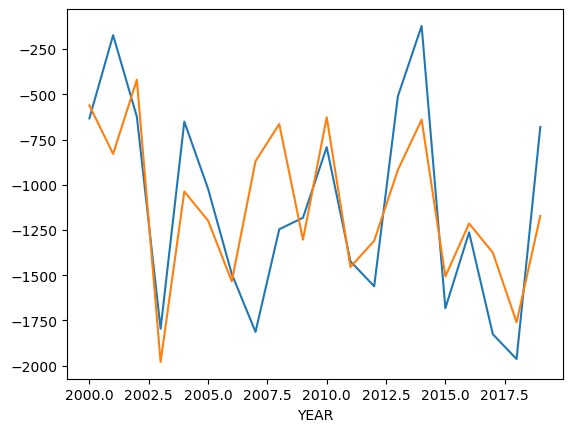

In [ ]:
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
mbmod = massbalance.MonthlyTIModel(gdir_hef, # Running the simulation with the set parameters
                                           melt_f=df['melt_f'],
                                           prcp_fac=df['prcp_fac'],
                                           temp_bias=df['temp_bias'],
                                           check_calib_params=False) 
        

mbdf['mod_mb_0'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=mbdf.index)

mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf['in_situ_mb'].plot()
mbdf['mod_mb_0'].plot()

print("The simulated mass balance is", mbdf['mod_mb_0'].mean())
print("The in-situ mass balance is", mbdf['in_situ_mb'].mean())

# The results showing the calibration of the three parameters with the rmsd minimization

Now I will experiment with another glacier with WGMS data to see if this works again

In [ ]:
from oggm.utils._downloads import get_wgms_files

clean_db = list(get_wgms_files())[0].drop([99])
clean_db

wgms_data_list = list(clean_db['RGI60_ID'])
wgms_data_list


base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdirs = workflow.init_glacier_directories(wgms_data_list, from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)

2025-11-20 12:02:09: oggm.workflow: init_glacier_directories from prepro level 4 on 289 glaciers.
2025-11-20 12:02:09: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 289 glaciers
2025-11-20 12:02:09: oggm.workflow: WARNING: you are trying to run an entity task on 289 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
  0% of 660.3 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% of 660.3 MiB |##                    | Elapsed Time: 0:00:15 ETA:   0:02:24
 19% of 660.3 MiB |####                  | Elapsed Time: 0:00:30 ETA:   0:02:07
 28% of 660.3 MiB |######                | Elapsed Time: 0:00:45 ETA:   0:01:54
 37% of 660.3 MiB |########              | Elapsed Time: 0:01:00 ETA:   0:01:38
 47% of 660.3 MiB |##########            | Elapsed Time: 0:01:15 ETA:   0:01:23
 56% of 660.3 MiB |############          | Elapsed Time: 0:01:30 ETA:   0:01:08
 66% of 660.3 MiB |##############        | Elapsed Time: 0:01:45 E

In [ ]:
gdirs[0]

# First glacier in the list
rgi_id = gdirs[0].rgi_id

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_new = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-11-20 11:40:16: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-20 11:40:16: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [ ]:
mbdf = gdir_new.get_ref_mb_data().loc[2000:2019] # WGMS data for new glacier

df = mb_calibration_from_wgms_mb(gdir_new,
                            ref_mb=mbdf['ANNUAL_BALANCE'],
                            overwrite_gdir=True,
                            mb_model_class=MonthlyTIModel,
                            calibrate_params= ('prcp_fac', 'melt_f', 'temp_bias'), # Changed to take in a tuple, this can allow us to change the order/number of parameters calibrated easily
                            melt_f_min=1.5,
                            melt_f_max=17.0,
                            temp_bias_min=-15.0,
                            temp_bias_max=15.0,
                            prcp_fac_min=0.1,
                            prcp_fac_max=10.0,
                            write_to_gdir=True)

df

2025-11-20 11:40:16: oggm.utils: You are trying to set MB data on a tidewater glacier! These data will be ignored by the MB model calibration routine.


[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


{'rgi_id': 'RGI60-19.00595',
 'bias': 0,
 'melt_f': 2.6474121476221595,
 'prcp_fac': 0.517819778602199,
 'temp_bias': 2.788709288268711,
 'reference_mb': -170.8,
 'reference_mb_err': 88.5,
 'reference_period': '[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013\n 2014 2015 2016 2017 2018 2019]',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

The simulated mass balance is -167.4593469781035
The in-situ mass balance is -170.8


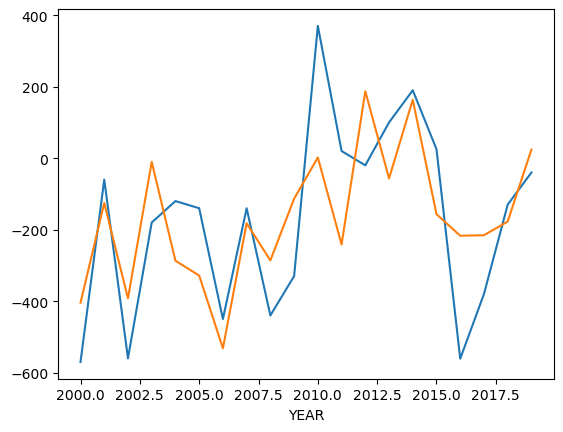

In [ ]:
mbdf['in_situ_mb'] = gdir_new.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
mbmod = massbalance.MonthlyTIModel(gdir_new, # Running the simulation with the set parameters
                                           melt_f=df['melt_f'],
                                           prcp_fac=df['prcp_fac'],
                                           temp_bias=df['temp_bias'],
                                           check_calib_params=False) 
        

mbdf['mod_mb_0'] = mbmod.get_specific_mb(fls=gdir_new.read_pickle('inversion_flowlines'), year=mbdf.index)

mbdf['in_situ_mb'] = gdir_new.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf['in_situ_mb'].plot()
mbdf['mod_mb_0'].plot()

print("The simulated mass balance is", mbdf['mod_mb_0'].mean())
print("The in-situ mass balance is", mbdf['in_situ_mb'].mean())

# The results showing the calibration of the three parameters with the rmsd minimization for the first glacier in the wgms list

This reduces the rmsd as much as possible, the mean here is a pretty decent fit. But the average mean is not matched exactly.

Running a diagnostic to calibrate all glaciers in our directory and storing the difference in the calculated rmsd and the mean.

In [ ]:
mean_differences = []
rmsds = []

gdir = gdirs[0]
for gdir in gdirs:
    df = mb_calibration_from_wgms_mb(gdir,
                                ref_mb=gdir.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE'], # Just calibrate for 2000-2019 for now
                                overwrite_gdir=True,
                                mb_model_class=MonthlyTIModel,
                                calibrate_params= ('prcp_fac', 'melt_f', 'temp_bias'), # Changed to take in a tuple, this can allow us to change the order/number of parameters calibrated easily
                                melt_f_min=1.5,
                                melt_f_max=17.0,
                                temp_bias_min=-15.0,
                                temp_bias_max=15.0,
                                prcp_fac_min=0.1,
                                prcp_fac_max=10.0,
                                write_to_gdir=True)
    
    rmsds.append(df['rmsd'])
    mean_differences.append(df['reference_mb'] - (massbalance.MonthlyTIModel(gdir,
                                           melt_f=df['melt_f'],
                                           prcp_fac=df['prcp_fac'],
                                           temp_bias=df['temp_bias'],
                                           check_calib_params=False).get_specific_mb(fls=gdir.read_pickle('inversion_flowlines'), year=np.arange(2000, 2020)).mean()))

NameError: name 'mb_calibration_from_wgms_mb' is not defined